In [32]:
# importing Necessary Libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

#### Data:

Importing Both Train and Test Data:
- Here, We are importing Both Train and Test Data.
- We will do Data Cleaning, EDA, Needed Feature Transformations on Training Data and Use Training Data to Build and Evaluate Model(s).
- At the end, We will use Test Data, apply same transformation steps on data as on Training Data and Use Model to Predict Target Variable.

In [3]:
# Trainig Data: For Data Cleaning, EDA, Feature Transformations, Model Training and Model Evaluations:
train_df = pd.read_csv('bigmart_train.csv')

# Test Data: To make Predictions Using Built Model:
test_df = pd.read_csv('bigmart_test.csv')

In [4]:
print(train_df.shape)
print(test_df.shape)

(8523, 12)
(5681, 11)


In [5]:
print(train_df.columns)
print(test_df.columns)

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')
Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')


#### EDA on Training Data:

In [9]:
train_df.head(7)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528


- Data has both Numerical (Continuous) and Categprical Features.

In [10]:
train_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


- Some Numercial Variable like Item Weight have missing values.
- Some variables like Item Visisbility, Item MRP, Item Outlet Sales seems to have Right Skewed Distribution (Due to Maximum value being too far from 75% Percentile Value) and possibly presense of Outliers.
- Outlet Establishment Year can be used to calculate Age of The Outlet.

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [15]:
# Missing Values Check:

train_df.isnull().sum() / len(train_df) * 100

Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64

- Item Weight (Numerical, Continuous) has 17.16% Missing Values.
- Outlet Size (Categorical, Ordinal) has 28.27% Missing Values.

##### 1) Handling Missing Values:

###### 1. Item Weight:

In [17]:
train_df['Item_Weight']

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64

In [18]:
train_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


- We should Check how strongly Item Weight Feature is correlated with other Item Related Features.
- Some of the Item Related Features are Categorical in Nature, which needs to be converted in Numerical for calculating Correlations with item Weight.

In [24]:
# Item Identifier:

train_df['Item_Identifier'].value_counts()

Item_Identifier
FDW13    10
FDG33    10
NCY18     9
FDD38     9
DRE49     9
         ..
FDY43     1
FDQ60     1
FDO33     1
DRF48     1
FDC23     1
Name: count, Length: 1559, dtype: int64

- We can Convert This Item identifiers Values to FD (Food), DR (Drink) and NC (Non-Consumable) Categories and Map them to Numericals.

In [27]:
train_df['Item_Identifier'].apply(lambda x: x[:2]).map({'FD': 0, 'DR': 1, 'NC': 2}).value_counts()

Item_Identifier
0    6125
2    1599
1     799
Name: count, dtype: int64

In [28]:
# Item Fat Content:

train_df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

- Low Fat and Regular have Multiple Represenations in Data.
- We can map them to single value.

In [33]:
train_df['Item_Fat_Content'].map({'Low Fat': 0,
                                  'LF': 0, 
                                  'low fat': 0, 
                                  'reg': 1,
                                 'Regular': 1}).value_counts()

Item_Fat_Content
0    5517
1    3006
Name: count, dtype: int64

In [31]:
# Item Type:

train_df['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

- We can use Simple Label Encoder here to convert each value to a numeric represenation.

In [40]:
# Function to Calculate Correlation of Item Weight to Other Item Related Features:

def item_w_corr(df):
    """
    Function to Change Categorical Item Related Features to Numericals and find Correlation of Item Weight Feature to other
    Item Related Features.
    """

    df = df.copy()

    df['Item_Identifier'] = df['Item_Identifier'].apply(lambda x: x[:2]).map({'FD': 0, 'DR': 1, 'NC': 2})
    df['Item_Fat_Content'] = df['Item_Fat_Content'].map({'Low Fat': 0,
                                  'LF': 0, 
                                  'low fat': 0, 
                                  'reg': 0,
                                 'Regular': 1})

    le = LabelEncoder()
    df['Item_Type'] = le.fit_transform(df['Item_Type'])

    sub_df = df[['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP']]

    corr_matrix = sub_df.corr()
    print(corr_matrix['Item_Weight'])

In [41]:
item_w_corr(train_df)

Item_Identifier     0.030399
Item_Weight         1.000000
Item_Fat_Content   -0.023375
Item_Visibility    -0.014048
Item_Type           0.030765
Item_MRP            0.027141
Name: Item_Weight, dtype: float64


As Item Weight has No Significant Correlation with any of The Item Related Features, we will Impute Missing Values with Mean or Median Depending on Distribution of the feature.

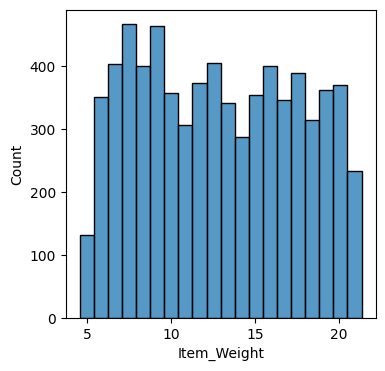

In [42]:
plt.figure(figsize= (4,4))
sns.histplot(data= train_df, x= 'Item_Weight')
plt.show()

- Distribution looks fairly Uniform.
- We can use Mean Imputation to handle Missing Values.
- Item Weight Feature will not require any kind of Transformations too.

**Dictionary to keep Track of Feature Wise Imputation Strategies and Transformations.**

dict = {
    
    'feature1' : {'imputer': 'mean', 'transform': 'log'},
    
    'feature2' : {'imputer': 'median', 'encoder': 'OneHot'}
}

In [43]:
preprocessing_dict = {
    'Item_Weight' : {'imputer': 'mean'}
}

###### 2) Outlet Size: